**<h1>Práctica computacional: modelo de Ising en 2D</h1>**

El objetivo de la práctica es calcular varios observables (magnetización, energía, susceptibilidad, calor específico) de una red de Ising bidimensional en función de la temperatura, y ver cómo a $T\simeq 2.27$ (usamos unidades en las que $J=k=1$) tiene lugar una transición de fase. También calcularemos la función de correlación y estudiaremos la dependencia de la longitud de correlación con la temperatura. Dado que el número de términos en la función de partición es gigantesco ($2^{100}$ para una red $10\times 10$, algo así como la edad del universo en décimas de picosegundo), no podemos aspirar a calcular la función de partición exactamente. En su lugar, lo que hacemos es generar estados aleatorios de la red distribuidos según el ensamble canónico, y tomar promedios sobre varios de esos estados. Para lograr eso, partimos de un estado inicial cualquiera y le aplicamos el **algoritmo de Metropolis**, que consta de los siguientes pasos:

1.   Elegimos un sitio de la red al azar.
2.   Calculamos la diferencia de energía $\Delta E$ que resultaría de darle vuelta a ese spin.
3. Si $\Delta E\le 0$, le damos vuelta al spin; si $\Delta E>0$, le damos vuelta al spin con probabilidad $e^{-\beta\Delta E}$.

Al estado resultante le volvemos a aplicar el algoritmo, y así sucesivamente. Después de ser iterado muchas veces, el algoritmo empieza a generar estados distribuidos según el ensamble canónico. Tomando promedios sobre varios de esos estados, podremos calcular los observables de interés.










# Bibliotecas

Importamos las bibliotecas de Python que vamos a usar: numpy, que permite definir y operar con matrices, genera números aleatorios, incluye todo tipo de funciones matemáticas, etc; matplotlib.pyplot, que permite hacer gráficos; y numba, que es un compilador que hace que las funciones corran mucho más rápido. También importamos la función curve_fit del paquete scipy.optimize, que nos servirá para hacer ajustes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.optimize import curve_fit

In [ ]:
-1%30

29

# Funciones

Aquí definimos dos funciones. La primera, **`h(S)`**, calcula la energía por partícula de la red en el estado **`S`** (nótese que **`S`** es una matriz de $1$'s y $-1$'s). Asumimos que no hay campo magnético y usamos condiciones de contorno periódicas, de manera que el primer spin de una fila/columna es vecino del último. Si la red es $L\times L$, la energía total es entonces

$$H(S)=-\sum_{i,j=1}^L S_{ij}(S_{i-1 j}+S_{ij-1}),$$

y la energía por partícula es esto dividido por $L^2$. La segunda función, **`metropolis(S,prob)`**, aplica el algoritmo de Metropolis al estado **`S`** y devuelve tres cosas: un nuevo estado **`S`**, el incremento de magnetización **`dm`** y el incremento de energía por partícula **`de`**. Deben notar que los únicos valores positivos que puede tomar el incremento de energía $\Delta E$ resultante de dar vuelta a un spin son $\Delta E=4$ y $\Delta E=8$; el argumento **`prob`** es un vector de dos componentes, **`prob[0]`** y **`prob[1]`**, que son las probabilidades con las que daremos vuelta al spin si el incremento de energía es $4$ y $8$ respectivamente.


*  Para calcular $\Delta E$ no se debe calcular la energía total de los dos estados (el estado original y el estado con el spin seleccionado dado vuelta) y restar, sino darse cuenta de que esta cantidad sólo involucra al estado del spin seleccionado y el de sus cuatro primeros vecinos.
*   Para dar vuelta a un spin con probabilidad $p$, lo que hacemos es generar un número aleatorio entre $0$ y $1$ y darle vuelta al spin si ese número es menor que $p$.


In [ ]:
@njit #Para que numba compile la función
def h(S): #Calcula la energía de la red en el estado S
    L = len(S)
    H = 0
    for i in range(L):
        for j in range(L):
            H = H - S[i][j]*(S[i-1][j]+S[i][j-1])
    h=H/L**2
    return(h)

@njit
def metropolis(S,prob):
    L = len(S)
    s = np.copy(S)
    for n in range(L**2):
        i = np.random.randint(L)
        j = np.random.randint(L)
        S_f = np.copy(s)
        S_f[i][j] = -S_f[i][j]

        E_f = -S_f[i%L][j%L]*(S_f[(i-1)%L][j%L] + S_f[(i+1)%L][j%L] + S_f[i%L][(j-1)%L] + S_f[i%L][(j+1)%L])
        E_i = -s[i%L][j%L]*(s[(i-1)%L][j%L] + s[(i+1)%L][j%L] + s[i%L][(j-1)%L] + s[i%L][(j+1)%L])

        delta_E = E_f - E_i

        if (delta_E <= 0):
            s = S_f

        elif (delta_E == 4):
            q = np.random.rand()
            if (q < prob[0]):
                s = S_f
            else:
                s = s

        elif (delta_E == 8):
            q = np.random.rand()
            if (q < prob[1]):
                s = S_f
            else:
                s = s

        else:
            s = s

    dm = np.mean(s)-np.mean(S)
    de = h(s)-h(S)
    return(s,dm,de)


S = np.ones((3,3),dtype=int)
prob=np.array([0.5,0.5])
print(metropolis(S,prob))

(array([[-1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1,  1]]), -0.2222222222222222, 0.8888888888888888)


**Explicación:**

Para la función $h(S)$ simplemente usamos la expresión tal cual como está en la celda "Funciones", ya que para python el elemento `[-1]` es el último elemento de la lista, que es justamente la condición de contorno que estabamos buscando. Para la suma doble usamos un doble `for` recorriendo todos los valores de $i,j$ de la matriz $S$, y por último dividimos por la cantidad de elementos de la matriz $(L^2)$ para hallar la energía por partícula.

En cuanto a la función metropolis no es más que un `for` iterando $L^2$ veces, donde en cada una de estas iteraciones calculamos la diferencia de energía de la nueva matriz `S_f`, que es la matriz `S` pero con el elemento $i,j$ random cambiado de signo. Preguntamos con la serie de "if's" si es necesario quedarnos con esta nueva matriz dependiendo de los valores que tome la diferencia de energía. Para el cálculo de ésta, lo que hicimos es calcular solamente la diferencia de energía asociada a los pares vecinos del spin que dimos vuelta, usando el recurso de que el resto entre el elemento $i$ o $j$ y $L$ nos da el elemento indicado para cumplir la periodicidad, cosa que no había aparecido en el cálculo de $h$ porque no era necesario calcular el elemento `[L+1]`. Por último calculamos la diferencia de magnetización y energía entre la primer configuración y la última obtenida luego del `for`.




# Termalización

Partiendo de un cierto estado inicial, estudiamos cuántos pasos son necesarios para que el sistema llegue al equilibrio, es decir, para que los distintos estados empiecen a estar distribuidos según el ensamble canónico. Para eso, graficamos la magnetización y la energía por partícula en función del paso; el equilibrio se alcanza cuando estas cantidades empiezan a fluctuar alrededor de un valor fijo, en lugar de ser netamente crecientes o decrecientes.
El número de pasos necesarios para alcanzar el equilibrio dependerá de la temperatura, así que hay que hay que hacer el análisis para varias temperaturas. También puede depender del lado de la red, así que cuando cambien el valor de este parámetro van a tener que rehacer este análisis. Fíjense que, cerca de la temperatura crítica, la magnetización oscila entre $1$ y $-1$.

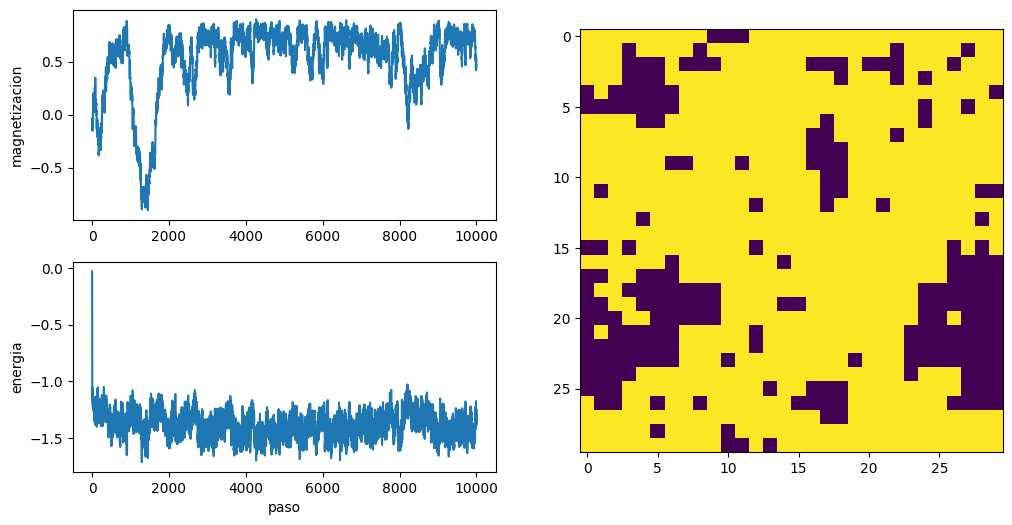

In [ ]:
L=30 #Lado de la red
beta=1/2.3

nequilibrio=10000 #Numero de pasos que proponemos para llegar al equilibrio

prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

#Estado inicial
#Opcion 1: todos los spines apuntan para arriba
#S=np.ones((L,L),dtype=int)
#Opcion 2: matriz aleatoria de 1's y -1's
S=2*np.random.randint(2,size=(L,L))-1

m=np.zeros(nequilibrio) #magnetización en función del paso
e=np.zeros(nequilibrio) #energia por particula en funcion del paso
m[0]=np.mean(S)
e[0]=h(S)

for n in range(1,nequilibrio):
  S,dm,de=metropolis(S,prob)
  m[n]=m[n-1]+dm
  e[n]=e[n-1]+de

plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.plot(m)
plt.ylabel('magnetizacion')
plt.subplot(2,2,3)
plt.plot(e)
plt.ylabel('energia')
plt.xlabel('paso')
plt.subplot(1,2,2)
plt.imshow(S) #plotea el estado final, dandole un color al 1 y otro al -1
plt.show()

# Promedios

Estudiamos cuántos pasos hacen falta para calcular buenos promedios. Para eso, graficamos el valor medio de la magnetización y la energía por partícula en función del número de pasos utilizados para calcularlo (empezando a contar después de haber llegado al equilibrio). Cuando el valor medio se haga constante, el número de pasos será suficiente. De vuelta, el número de pasos apropiado depende de la temperatura y del lado de la red. Van a ver que, cerca de la temperatura crítica, las fluctuaciones se hacen más grandes y por lo tanto es necesario promediar sobre un número más grande de pasos. Para librarnos de las fluctuaciones de la magnetización entre $1$ y $-1$ cerca de la temperatura crítica, que son inmanejables, lo que tomamos es el valor medio de su módulo.

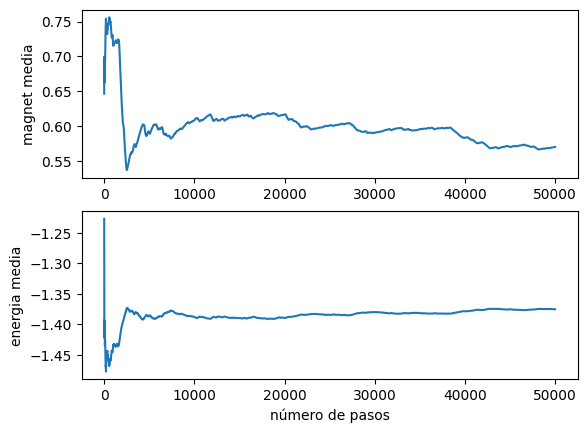

CPU times: user 29.3 s, sys: 239 ms, total: 29.6 s
Wall time: 39.8 s


In [ ]:
%%time
L=30
beta=1/2.3

nequilibrio=10000 #Este valor lo decidimos en base a lo anterior
npromedio=50000 #Numero de pasos tentativo para calcular promedios

prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

S=np.ones((L,L),dtype=int) #Estado inicial

for n in range(nequilibrio):
  S,dm,de=metropolis(S,prob) #Termalizamos

m=np.zeros(npromedio)
e=np.zeros(npromedio) #Magnetizacion y energia por particula en funcion del paso
m[0]=np.mean(S)
e[0]=h(S)

mmedia=[abs(m[0])]
emedia=[e[0]] #Valores medios en funcion del numero de pasos para promediar

for n in range(1,npromedio):
  S,dm,de=metropolis(S,prob)
  m[n]=m[n-1]+dm
  e[n]=e[n-1]+de
  mmedia.append(np.mean(abs(m[0:n+1])))
  emedia.append(np.mean(e[0:n+1]))

plt.figure()
plt.subplot(2,1,1)
plt.plot(mmedia)
plt.ylabel('magnet media')
plt.subplot(2,1,2)
plt.plot(emedia)
plt.ylabel('energia media')
plt.xlabel('número de pasos')
plt.show()

# Transición de fase

Aquí hay que calcular la magnetización media, la energía media por partícula, la susceptibilidad y el calor específico para varias temperaturas, graficar el resultado y ver que a una temperatura cercana a la crítica se produce un comportamiento casi brusco. Algunos consejos:

*   Para calcular la susceptibilidad y el calor específico no hay que tomar ninguna derivada, hay que usar la relación entre estas cantidades y la varianza de la magnetización y la energía por partícula respectivamente.
*   No propongan un nuevo estado inicial para cada temperatura: aprovechen el último estado de la temperatura anterior, porque así van a necesitar menos pasos para termalizar. Si empiezan a temperaturas bajas, conviene tomar como estado inicial la matriz de $1$'s, y si empiezan a temperaturas altas conviene tomar como estado inicial una matriz aleatoria de $1$'s y $-1$'s.
*   Quizá conviene dar más pasos para termalizar y/o tomar promedios cerca de la temperatura crítica que lejos de ella.





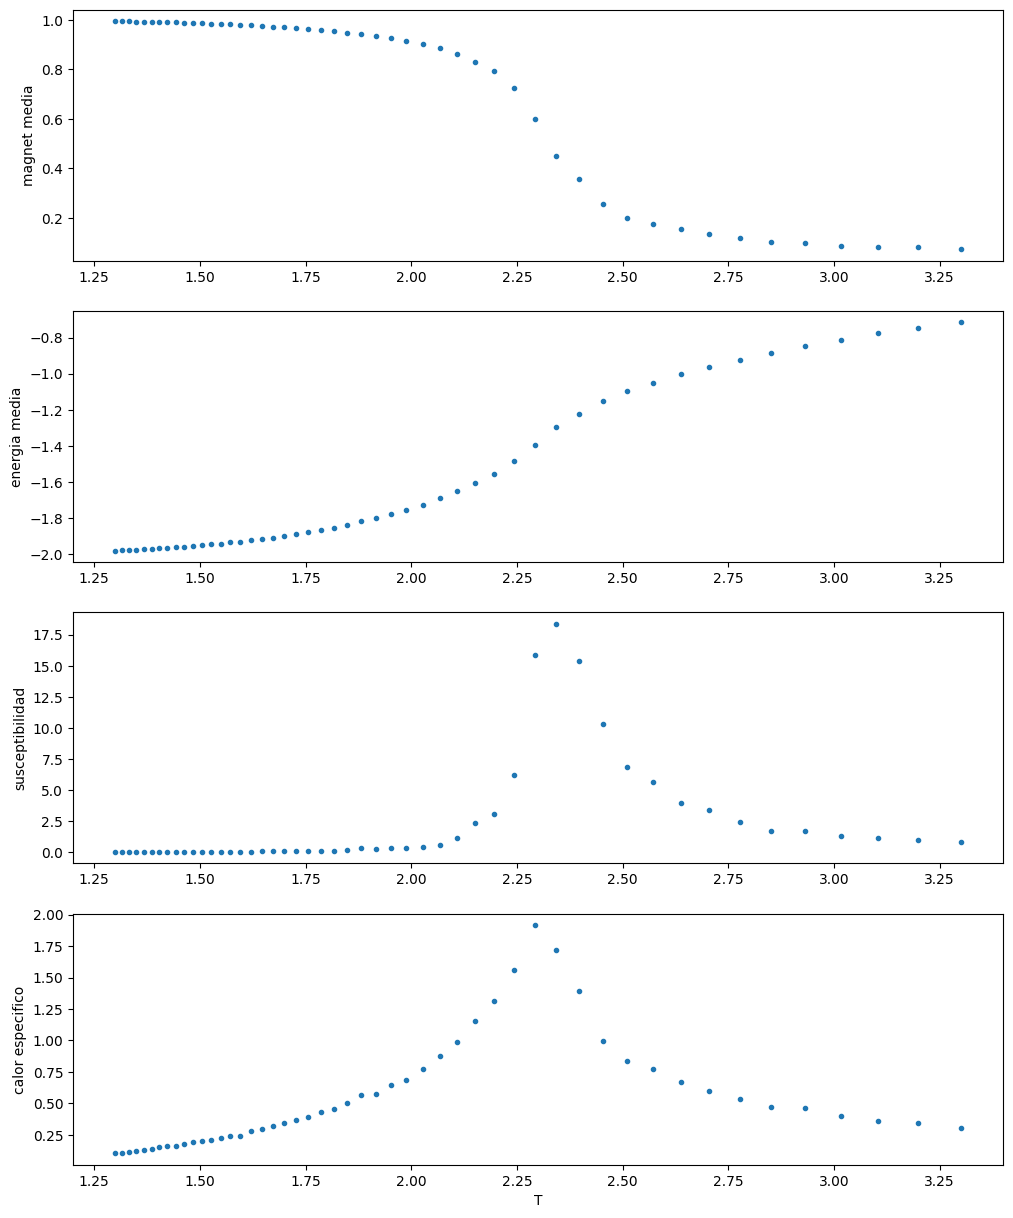

CPU times: user 3min 55s, sys: 591 ms, total: 3min 56s
Wall time: 3min 58s


In [ ]:
%%time
L=30

rango_beta = np.linspace(1/(2.3+1),1/(2.3-1),50)
T = 1/rango_beta
mag_media = []
ener_media = []
susceptibilidad = []
calor_especifico = []

# S=np.ones((L,L),dtype=int) #Estado inicial

S=2*np.random.randint(2,size=(L,L))-1 #Opcion 2: matriz aleatoria de 1's y -1's


for beta in (rango_beta):
    temp = 1/beta
    if temp<1.6 or temp>2.75: #Lejos de la temperatura crítica
        nequilibrio = 350
        npromedio = 5000 #Numero de pasos tentativo para calcular promedios
    else:
        nequilibrio = 700
        npromedio = 20000

    prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

    for n in range(nequilibrio):
        S,dm,de=metropolis(S,prob) #Termalizamos

    m=np.zeros(npromedio)
    e=np.zeros(npromedio) #Magnetizacion y energia por particula en funcion del paso
    m[0]=np.mean(S)
    e[0]=h(S)

    for n in range(1,npromedio):
        S,dm,de=metropolis(S,prob)
        m[n]=m[n-1]+dm
        e[n]=e[n-1]+de

    mmedia = np.mean(abs(m))
    emedia = np.mean(e)
    suscep =  (np.mean(m**2) - mmedia**2)*beta*(L**2)
    calor_esp = (np.mean(e**2) - emedia**2)*(beta**2)*(L**2)
    mag_media.append(mmedia)
    ener_media.append(emedia)
    susceptibilidad.append(suscep)
    calor_especifico.append(calor_esp)

plt.figure(figsize=[12,15])
plt.subplot(4,1,1)
plt.plot(T,mag_media,'o',markersize=3)
plt.ylabel('magnet media')
plt.subplot(4,1,2)
plt.plot(T,ener_media,'o',markersize=3)
plt.ylabel('energia media')
plt.subplot(4,1,3)
plt.plot(T,susceptibilidad,'o',markersize=3)
plt.ylabel('susceptibilidad')
plt.subplot(4,1,4)
plt.plot(T,calor_especifico,'o',markersize=3)
plt.ylabel('calor especifico')
plt.xlabel('T')
plt.show()

**Explicación:**

Iniciamos definiendo el array de temperaturas en las que nos interesa calcular la energía, la magnetización, la susceptibilidad y el calor específico. Teniendo en cuenta lo visto en las anteriores celdas, es decir, cuántos pasos son necesarios primero que nada para alcanzar el equilibrio de la función metropolis y luego la cantidad de pasos necesarios para promediar las cantidades de interés, usamos un `for` para recorrer estas temperaturas, diferenciando la cantidad de pasos en los casos donde la temperatura es cercana a la crítica. Para hallar la susceptibilidad y el calor específico usamos las siguientes ecuaciones que relacionan estas cantidades con las varianzas de la energía y la magnetización.
\begin{align}
\Delta m^2 &= \cfrac{\chi}{\beta N}\\
\Delta h^2 &= \cfrac{kT^2 C_v}{ N}
\end{align}

Donde $N$ es el número de partículas, en este caso $N = L^2$.


# Correlaciones

La **función de correlación** se define como $g(r)=\langle s_{ij}s_{ij+r}\rangle-\langle s_{ij}\rangle\langle s_{ij+r}\rangle$, y se sabe que tiene la forma $g(r)=ae^{-r/\xi}$. A $\xi$ se lo conoce como la **longitud de correlación**, y es una función de la temperatura que, en el límite termodinámico, diverge a la temperatura crítica. El objetivo de esta sección es ver eso.

Lo primero que hay que hacer es definir dos funciones. La primera, **`cor(S)`**, devuelve un vector $c$ de $L/2$ componentes, donde $L$ es el lado de la red, cuya componente $r$ es el promedio de $s_{ij}s_{ij+r}$ sobre toda la red, es decir,

$c(r)=\frac{1}{L^2}\sum_{i,j=1}^Ls_{ij}s_{ij+r}.$

La segunda función, **`metropolis2(S,prob)`**, implementa el algoritmo de Metropolis, igual que hacía la función **`metropolis(S,prob)`**, pero esta vez, en lugar de devolver el nuevo estado, el incremento de la magnetización y el incremento de energía, devuelve el nuevo estado, el incremento de la magnetización y el incremento del vector $c$. Para definir estas dos funciones deberán prestar mucha atención a las condiciones de contorno periódicas, y tener en cuenta que $c(0)=1$ independientemente del estado, así que el incremento de $c(0)$ siempre es $0$.

In [ ]:

@njit
def cor(S):
    L = len(S)
    c = np.zeros(int(L/2))
    for r in range(int(L/2)):
        c_n = 0
        for i in range(L):
            for j in range(L):
                c_n = c_n + S[i][j]*S[i][(j+r)%L]
        c[r] = c_n
    return(c/L**2)


@njit
def metropolis2(S,prob):
    L = len(S)
    s = np.copy(S)
    for n in range(L**2):
        i = np.random.randint(L)
        j = np.random.randint(L)
        S_f = np.copy(s)
        S_f[i][j] = -S_f[i][j]

        E_f = -S_f[i%L][j%L]*(S_f[(i-1)%L][j%L] + S_f[(i+1)%L][j%L] + S_f[i%L][(j-1)%L] + S_f[i%L][(j+1)%L])
        E_i = -s[i%L][j%L]*(s[(i-1)%L][j%L] + s[(i+1)%L][j%L] + s[i%L][(j-1)%L] + s[i%L][(j+1)%L])

        delta_E = E_f - E_i

        if (delta_E <= 0):
            s = S_f

        elif (delta_E == 4):
            q = np.random.rand()
            if (q < prob[0]):
                s = S_f
            else:
                s = s

        elif (delta_E == 8):
            q = np.random.rand()
            if (q < prob[1]):
                s = S_f
            else:
                s = s

        else:
            s = s

    dm = np.mean(s)-np.mean(S)
    dc = cor(s)-cor(S)

    return(s,dm,dc)

L = 4
S = np.ones((L,L),dtype=int)
prob = np.array([1,1])

metropolis2(S,prob)


(array([[ 1,  1,  1,  1],
        [-1, -1, -1,  1],
        [ 1, -1, -1, -1],
        [ 1,  1,  1,  1]]),
 -0.75,
 array([ 0. , -0.5]))

**Explicación:**

Para la función `cor(S)` planteamos un `for` para iterar $L/2$ veces sobre $r$ y en cada una realizamos la suma sobre los spines con un doble `for`, usando el mismo recurso del resto para que se cumpla la periodicidad. Por último se "apendean" en la lista `c` los valores de $c(r)$ para cada $r$ y le pedimos a la función que devuelva esta lista pero dividiendo cada elemento por $L^2$.

Para la función `metropolis2` hicimos casi exactamente lo mismo que para `metropolis` pero le pedimos al final que devuelva la diferencia entre la función de correlación de el $S$ inicial y el $S$ final.  









Ahora usamos las funciones que acabamos de definir para calcular la función de correlación a tres temperaturas distintas. Ajustamos los datos obtenidos con una función de la forma $a e^{-r/\xi}$, y de ahí obtenemos la longitud de correlación a esas tres temperaturas.

Longitud de correlacion:
T=1.5 => 0.41666339336133373
T=2.3 => 2.3722092994044015
T=3 => 1.1739629308886919


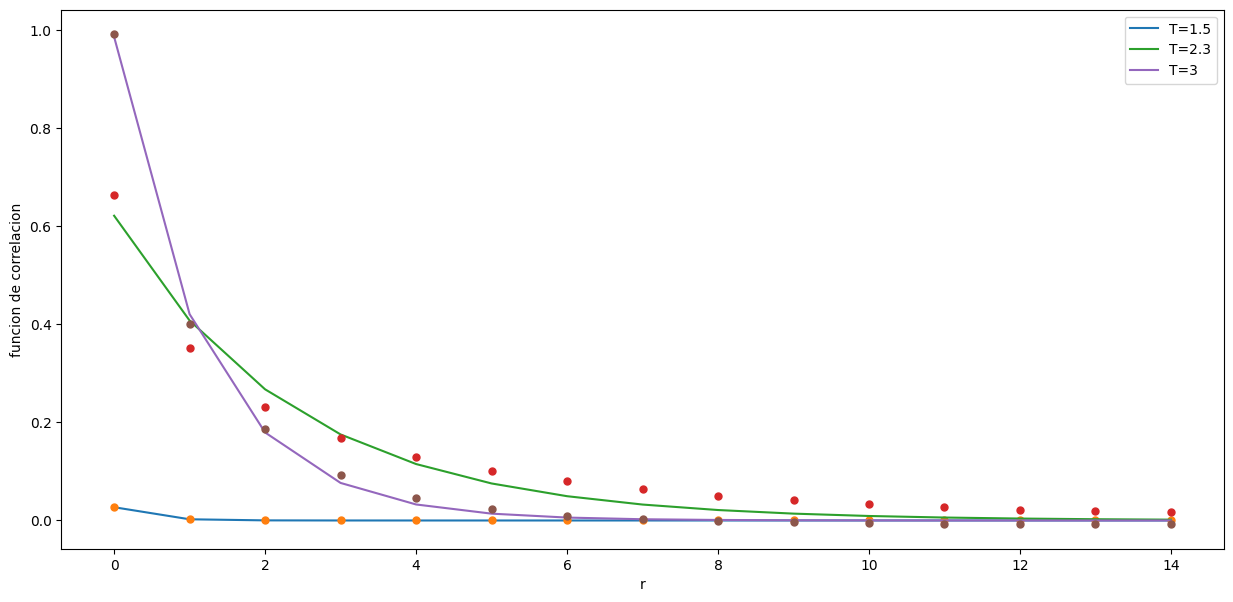

CPU times: user 1min 24s, sys: 1.26 s, total: 1min 25s
Wall time: 1min 25s


In [ ]:
%%time

L=30

nequilibrio=1000
npromedio=50000

l=int(L/2) #numero de componentes del vector c
m=np.zeros(npromedio) #magnetizacion en funcion del paso
c=np.zeros((l,npromedio)) #vector c en funcion del paso

erres=np.arange(l) #dominio de la funcion de correlacion
def fitcor(r,a,xi): #funcion con la que vamos a ajustar
  return a*np.exp(-r/xi)

S=np.ones((L,L),dtype=int)

print('Longitud de correlacion:')
plt.figure(figsize=[15,7])
for T in [1.5,2.3,3]:

  beta=1/T

  prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

  #Termalizamos con la funcion metropolis(S,prob), que es mas rapida
  for n in range(nequilibrio):
    S,dm,de=metropolis(S,prob)

  m[0]=np.mean(S)
  c[:,0]=cor(S)

  for n in range(1,npromedio):
    S,dm,dc=metropolis2(S,prob)
    m[n]=m[n-1]+dm
    c[:,n]=c[:,n-1]+dc

  mmedia=np.mean(abs(m))
  correlacion=np.mean(c,axis=1)-mmedia**2 #funcion de correlacion

  #Ajustamos:
  parametros,covarianza=curve_fit(fitcor,erres,correlacion)
  #(la funcion curve_fit devuelve el mejor valor de los parametros
  #y tambien la covarianza, que no vamos a usar)

  print('T={} => {}'.format(T,parametros[1]))

  plt.plot(erres,fitcor(erres,parametros[0],parametros[1]),label='T={}'.format(T))
  plt.plot(erres,correlacion,'o',markersize=5)

plt.xlabel('r')
plt.ylabel('funcion de correlacion')
plt.legend()
plt.show()

Por último, hay que barrer un rango de temperaturas que incluya la crítica y
obtener un gráfico de la longitud de correlación en función de la temperatura.

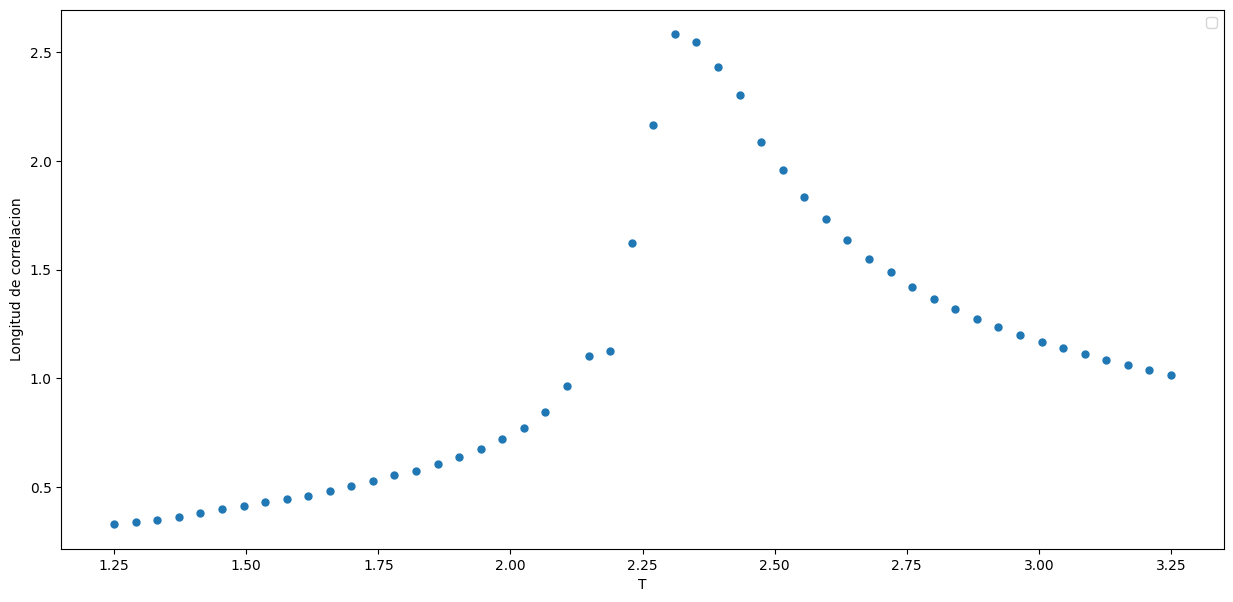

CPU times: user 22min 51s, sys: 14.4 s, total: 23min 6s
Wall time: 23min 3s


In [ ]:
%%time

L=30

nequilibrio=1000
npromedio=50000

l=int(L/2) #numero de componentes del vector c
m=np.zeros(npromedio) #magnetizacion en funcion del paso
c=np.zeros((l,npromedio)) #vector c en funcion del paso

erres=np.arange(l) #dominio de la funcion de correlacion
def fitcor(r,a,xi): #funcion con la que vamos a ajustar
    return a*np.exp(-r/xi)

S=np.ones((L,L),dtype=int)

# print('Longitud de correlacion:')

rango_temp = np.linspace(1.25,3.25,50)
long_c = []

for T in rango_temp:

    beta=1/T

    prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

    #Termalizamos con la funcion metropolis(S,prob), que es mas rapida
    for n in range(nequilibrio):
        S,dm,de=metropolis(S,prob)

    m[0]=np.mean(S)
    c[:,0]=cor(S)

    for n in range(1,npromedio):
        S,dm,dc=metropolis2(S,prob)
        m[n]=m[n-1]+dm
        c[:,n]=c[:,n-1]+dc

    mmedia=np.mean(abs(m))
    correlacion=np.mean(c,axis=1)-mmedia**2 #funcion de correlacion

    #Ajustamos:
    parametros,covarianza=curve_fit(fitcor,erres,correlacion)
    #(la funcion curve_fit devuelve el mejor valor de los parametros
    #y tambien la covarianza, que no vamos a usar)

    long_c.append(parametros[1])


plt.figure(figsize=[15,7])
plt.plot(rango_temp,long_c,'o',markersize=5)
plt.xlabel('T')
plt.ylabel('Longitud de correlacion')
plt.legend()
plt.show()

**Explicación:**

En este caso lo que hicimos fue usar la estructura del código de la celda anterior, en este caso recorriendo una mayor cantidad de temperaturas (50), y nos quedamos únicamente con `parametros[1]` que es el parámetro del ajuste que corresponde a la longitud de correlación.


# Temperatura crítica

La teoría de **finite-size scaling** (Fisher y Barber, Physical Review Letters 28, 1972) muestra que, para una red de Ising bidimensional de lado $L$, el pico de la susceptibilidad ocurre a una temperatura $T_c(L)$ dada por

$$T_c(L)=T_c+\frac{a}{L},$$

donde $T_c$ es la temperatura crítica del sistema en el límite termodinámico y $a$ es una constante. Lo que deben hacer en esta sección es determinar $T_c(L)$ para $L=15,30,60,120$ con una precisión aproximada de $0.01$, graficar en función de $1/L$, ajustar los puntos a una recta y de ahí obtener una estimación para la temperatura crítica.

In [ ]:
%%time

L = 120
T = np.linspace(2.26,2.31,6)
rango_beta = 1/T
nequilibrio = 10000
npromedio = 30000

S=2*np.random.randint(2,size=(L,L))-1
susceptibilidad = []

for beta in (rango_beta):
    prob=np.array([np.exp(-4*beta),np.exp(-8*beta)])

    for n in range(nequilibrio):
        S,dm,de=metropolis(S,prob) #Termalizamos

    m=np.zeros(npromedio)
    m[0]=np.mean(S)

    for n in range(1,npromedio):
        S,dm,de=metropolis(S,prob)
        m[n]=m[n-1]+dm

    mmedia=np.mean(abs(m))
    suscep =  (np.mean(m**2) - mmedia**2)*beta*(L**2)
    susceptibilidad.append(suscep)

plt.figure()
plt.plot(T,susceptibilidad,'o',markersize=5)
plt.xticks(T)
plt.grid()
plt.ylabel('susceptibilidad')
plt.xlabel('T')
plt.title('L = 120')
plt.savefig('Tc - L120')
plt.show()

In [ ]:
T15 = np.array([2.4056,2.455,2.42,2.42,2.42,2.42,2.385,2.42,2.42,2.455])
T15_mean = np.mean(T15)

T30 = np.array([2.385,2.385,2.350,2.350,2.350,2.350,2.350,2.315,2.315,(2.245+2.350)/2])
T30_mean = np.mean(T30)

T60 = np.array([2.35,2.32,2.29,2.26,2.28,2.30,2.32,2.32,2.32,2.30])
T60_mean = np.mean(T60)

T120 = np.array([2.29,2.28,2.30])
T120_mean = np.mean(T120)

T_c = np.array([T15_mean,T30_mean,T60_mean,T120_mean])
L = np.array([15,30,60,120])

def fittemp(l,a,t): #funcion con la que vamos a ajustar
    return (t + a/l)

parametros,covarianza=curve_fit(fittemp,L,T_c)


plt.errorbar(1/L,T_c,yerr=0.01,marker='o',linestyle='')
plt.plot(1/L,fittemp(L,parametros[0],parametros[1]))
plt.xlabel('$1/L$')
plt.ylabel('$T_c(1/L)$')
plt.grid()
plt.show()
print('Temperatura crítica en el límite termodinámico => Tc = {}'.format(parametros[1]))

**Explicación:**

En estas últimas celdas lo que hicimos fue ir graficando la susceptibilidad para los diferentes valores de $L$ y en cada uno de ellos fuimos acortando la ventana de temperaturas cercanas al máximo de la susceptibilidad. Repetimos el proceso 10 veces para cada $L$ y tomamos un promedio de la temperatura crítica que obteniamos en cada caso, excepto para $L=120$ que nos demoraba aproximadamente 3 horas cada gráfico.

[L=15](https://drive.google.com/file/d/17Flx0APJqwr5Kw5Fj4wqHACgSYKasO6j/view?usp=sharing), [L=30](https://drive.google.com/file/d/11jvdCnSrFza6j4JXHoSqNOOyDrgDXqO8/view?usp=sharing), [L=60](https://drive.google.com/file/d/1Ex8df6BIVDYKOq2ClEH9tDrJ6DLXyzVC/view?usp=sharing)

 Una vez hallada la temperatura crítica para cada valor de $L$ lo que hicimos fue realizar un ajuste de los puntos con la función `fittemp` y buscar el parámetro asociado a la ordenada al origen de la recta, que es justamente la temperatura crítica en el límite termodinámico $(L \to \infty)$.

# Discusión


Pudimos observar la magnetización, energía, calor específico y susceptibilidad en función de la temperatura, en donde pudimos ver que a medida que se acerca a la temperatura crítica los gráficos de la susceptibilidad, el calor específico y la longitud de correlación (red finita) alcanzan su máximo.
La temperatura crítica para el límite termodinámico que obtuvimos es la siguiente:

$$T_c = 2.27 \pm 0.01$$

Y considerando que la solución exacta de Onsager es $T_c = \cfrac{2}{\ln{(\sqrt{2}+1)}}  \approx 2.269 $, el resultado que obtuvimos computacionalmente es una muy buena aproximación, a diferencia del resultado de usar la aproximación de campo medio para una red 2D, $T_c = 4$.